In [1]:
# =============================================================================
#  TAHAP 0 — KONFIGURASI & KONSTANTA (Centralized)
#  Single source of truth untuk semua hyperparameter, paths, dan magic numbers
# =============================================================================

# ============== FILE I/O CONSTANTS ==============
DATASET_PATH = "rbsqli_dataset.csv"
MODEL_PATH = "model_sqli_nb.pkl"
CSV_USECOLS = [0, 1, 2]
CSV_DTYPES = {0: str, 1: str, 2: str}

# ============== PREPROCESSING & NLP CONSTANTS ==============
JUMLAH_JOBS = 8  # Parallel jobs untuk preprocessing (3 Physical Cores)

# Pre-compiled regex patterns untuk performa optimal
REGEX_SINGLE_QUOTE = r"'[^']*'"
REGEX_DOUBLE_QUOTE = r'"[^"]*"'
REGEX_DIGITS = r'\d+'
REGEX_TOKENS = r"[a-z0-9_]+|--|/\*|\*/|'|\"|\(|\)|=|<|>|;|#|,|\*|\+|-|%"

# Linguistic constants
STOPWORDS = {
    "a", "an", "the", "is", "it", "in", "on", "at", "to", "for",
    "of", "and", "with", "by", "as", "be", "was", "are", "were",
    "this", "that", "have", "has", "had", "do", "does", "did",
    "but", "so", "if", "then", "than", "its", "into", "from",
    "there", "their", "they", "will", "would", "could", "should"
}

SQL_KEYWORDS = {
    "select", "from", "where", "and", "or", "not", "is", "in",
    "like", "union", "insert", "update", "delete", "drop", "create",
    "table", "into", "values", "order", "by", "group", "having",
    "join", "on", "null", "true", "false", "case", "when", "then",
    "else", "end", "limit", "offset", "between", "exists", "all",
    "distinct", "count", "sum", "max", "min", "avg", "sleep",
    "benchmark", "char", "concat", "substring", "load_file",
    "outfile", "exec", "execute", "cast", "convert", "if"
}

FUZZY_RATIO_THRESHOLD = 90  # Threshold untuk deteksi leakage

# ============== DATA BALANCING CONSTANTS ==============
TARGET_PER_KATEGORI = 15000  # Target baris per kategori SQLi
KATEGORI_TARGET = [
    'Error-Based', 'meta_based', 'stackqueries_based', 
    'Time-Based', 'Union-Based', 'boolean-based'
]

# ============== TRAIN-TEST SPLIT CONSTANTS ==============
TEST_SIZE = 0.2
RANDOM_STATE = 42

# ============== MODEL HYPERPARAMETERS ==============
# TF-IDF Configuration
TFIDF_ANALYZER = "word"
TFIDF_NGRAM_RANGE = (1, 3)
TFIDF_MIN_DF = 2
TFIDF_MAX_FEATURES = 5000
TFIDF_SUBLINEAR_TF = True
TFIDF_TOKEN_PATTERN = r"\S+"

# Naive Bayes Configuration
NB_ALPHA = 0.1

# Cross-Validation Configuration
CV_N_SPLITS = 5

# ============== DISPLAY CONSTANTS ==============
SEPARATOR_LONG = "=" * 65
SEPARATOR_MEDIUM = "─" * 40
SEPARATOR_SHORT = "─" * 60
MAX_DISPLAY_LENGTH = 200
MAX_EXAMPLES = 5

# Classification targets untuk reporting
CLASSIFICATION_TARGETS = ["Normal (0)", "SQLI (1)"]

In [2]:
# =============================================================================
#  UTILITAS BERSAMA
# Catatan kelompok import (tujuan & peran):
#  - Standar Python : os (env/path), re (regex), gc (garbage collector),
#                     time (latency), warnings (suppress warning),
#                     joblib (serialisasi model & parallel backend).
#  - Komputasi       : numpy (array/matrix), pandas (DataFrame I/O),
#                     joblib.Parallel (multiprocessing),
#                     rapidfuzz (fuzzy string matching berbasis C),
#                     itertools.chain (flatten list hemat memori),
#                     IPython.display (render output cantik).
#  - scikit-learn    : TfidfVectorizer (vektorisasi teks),
#                     MultinomialNB (klasifikasi probabilistik),
#                     Pipeline (rantai preprocessing + estimator),
#                     train_test_split, StratifiedKFold, cross_val_score,
#                     serta metrik (accuracy, precision, recall, f1,
#                     confusion_matrix, classification_report).
#  Dipakai oleh tahap training, inferensi, dan export hasil
# =============================================================================

import os
import re
import gc
import time
import warnings
import joblib
import numpy as np
import pandas as pd
from itertools import chain
from IPython.display import display
from joblib import Parallel, delayed
from rapidfuzz import process, fuzz
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

warnings.filterwarnings("ignore")

In [3]:
# =============================================================================
#  1. PRE-COMPILE REGEX PATTERNS & SET REDUCTION (Optimasi Memori & Kecepatan)
# =============================================================================
# Menggabungkan operasi set untuk eliminasi double-lookup di dalam loop teks
DROPPED_WORDS = STOPWORDS - SQL_KEYWORDS

REGEX_SINGLE_QUOTE = re.compile(r"'[^']*'")
REGEX_DOUBLE_QUOTE = re.compile(r'"[^"]*"')
REGEX_DIGITS = re.compile(r'\d+')
REGEX_TOKENS = re.compile(r"[a-z0-9_]+|--|/\*|\*/|'|\"|\(|\)|=|<|>|;|\#|,|\*|\+|\-|%")

def preprocess_text(text):
    """
    Fungsi preprocessing teks versi optimasi tinggi.
    Menggunakan single lookup berbasis reduksi set logika untuk performa maksimal.
    """
    if not isinstance(text, str):
        return ""
    
    # 1. Normalisasi case di awal
    text = text.lower()

    # 2. Eksekusi Regex terkompilasi
    text = REGEX_SINGLE_QUOTE.sub("'str'", text)
    text = REGEX_DOUBLE_QUOTE.sub('"str"', text)
    text = REGEX_DIGITS.sub('0', text)

    # 3. Tokenisasi cepat
    tokens = REGEX_TOKENS.findall(text)

    # 4. OPTIMASI LOOP: Mengurangi beban lookup ganda menjadi single lookup
    filtered = [t for t in tokens if t not in DROPPED_WORDS]

    return " ".join(tokens)

def proses_blok_kebocoran(test_chunk, train_list, threshold):
    """
    Memproses pengecekan kebocoran per blok data untuk meminimalkan overhead.
    Menggunakan C++ level loop dari rapidfuzz dengan fitur early exit.
    """
    hasil = []
    for q in test_chunk:
        # extractOne langsung mengeliminasi string yang panjangnya tidak ideal (length filtering)
        res = process.extractOne(
            q, 
            train_list, 
            scorer=fuzz.ratio, 
            score_cutoff=threshold
        )
        # Jika res tidak None, berarti ada kecocokan di atas threshold (Bocor)
        hasil.append(res is not None)
    return hasil



In [20]:
# =============================================================================
#  TAHAP 1 — MEMUAT & VALIDASI DATASET
# =============================================================================

print(SEPARATOR_LONG)
print("    SISTEM DETEKSI SQL INJECTION — MULTINOMIAL NAÏVE BAYES")
print(SEPARATOR_LONG)

# Pemuatan data dengan optimasi memori (C-Engine)
start_time = time.time()
df = pd.read_csv(
    DATASET_PATH,
    usecols=CSV_USECOLS,
    dtype=CSV_DTYPES,
    engine='c',
    low_memory=False
)
df.columns = ["Query", "Category", "Label"]
loading_time = time.time() - start_time

# --- OUTPUT EDA STANDAR AKADEMIS ---
print(f"[1] Ringkasan Dataset (df.info())")
df.info(memory_usage='deep') # Menampilkan real penggunaan RAM untuk tipe string
print(f"Waktu Muat Data : {loading_time:.2f} detik")

print(f"\n[2] Validasi Nilai Kosong (Missing Values)")
# Output langsung menampilkan format kolom dan jumlah yang kosong (bukti otentik)
print(df.isnull().sum().to_string()) 

print(f"\n[3] Distribusi Kategori Serangan SQLi")
kategori_unik = df['Category'].unique().tolist()
print(f"Total Kategori  : {len(kategori_unik)}")
print(f"Daftar Kategori : {kategori_unik}")
print(SEPARATOR_LONG)

    SISTEM DETEKSI SQL INJECTION — MULTINOMIAL NAÏVE BAYES
[1] Ringkasan Dataset (df.info())
<class 'pandas.DataFrame'>
RangeIndex: 10190450 entries, 0 to 10190449
Data columns (total 3 columns):
 #   Column    Dtype
---  ------    -----
 0   Query     str  
 1   Category  str  
 2   Label     str  
dtypes: str(3)
memory usage: 2.3 GB
Waktu Muat Data : 32.62 detik

[2] Validasi Nilai Kosong (Missing Values)
Query       0
Category    0
Label       0

[3] Distribusi Kategori Serangan SQLi
Total Kategori  : 7
Daftar Kategori : ['None_Type', 'Error-Based', 'meta_based', 'stackqueries_based', 'Time-Based', 'Union-Based', 'boolean-based']


In [5]:
# =============================================================================
#  TAHAP 2 — PREPROCESSING OTOMATIS (VERSI CHUNK PARALLEL & HEMAT RAM - REVISI)
# =============================================================================

print("\n[2] PREPROCESSING OTOMATIS (ALOKASI TERBATAS)")

sebelum = len(df)

# 1. Hapus baris dengan nilai kosong (In-place untuk hemat RAM)
df.dropna(subset=["Query", "Label"], inplace=True)
print(f"    Hapus baris kosong       : {sebelum - len(df)} baris dihapus")

# 2. Normalisasi format Label
df["Label"] = (
    df["Label"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({"yes": "1", "no": "0"})
)
df = df[df["Label"].str.match(r"^[01]$")]
df["Label"] = df["Label"].astype(np.int8)  # Menggunakan int8 (1 byte) menggantikan int64 (8 bytes)
print(f"    Setelah filter Label     : {len(df)} baris valid")

# 3. Lowercase in-place pada kolom asli untuk mencegah duplikasi array raksasa
print("    Melakukan lowercase awal pada seluruh data mentah...")
df["Query"] = df["Query"].astype(str).str.lower()

sebelum_lowercase_dup = len(df)
df.drop_duplicates(subset=["Query"], inplace=True)
print(f"    Duplikat berbasis lowercase dihapus: {sebelum_lowercase_dup - len(df)} baris")

print(f"    -> Mendeteksi {os.cpu_count()} Logical Processors di sistem.")
print(f"    -> Mengaktifkan {JUMLAH_JOBS} Logical Processors")

# OPTIMASI UTAMA: Pemrosesan paralel berbasis CHUNK untuk mencegah RAM OOM
N_CHUNKS = JUMLAH_JOBS * 4
chunks = np.array_split(df["Query"], N_CHUNKS)

def proses_chunk_array(chunk):
    """
    Memproses potongan array menggunakan list comprehension murni.
    Kompatibel baik dengan objek NumPy ndarray maupun Pandas Series.
    """
    return [preprocess_text(x) for x in chunk]

print("    Memproses preprocessing paralel berbasis chunk...")
hasil_paralel = Parallel(n_jobs=JUMLAH_JOBS, backend="loky")(
    delayed(proses_chunk_array)(chunk) for chunk in chunks
)

# Gabungkan hasil chunk secara instan ke kolom baru menggunakan itertools.chain (Sangat Cepat & Hemat RAM)
df["Query_clean"] = list(chain.from_iterable(hasil_paralel))
print("    Preprocessing paralel selesai!")

# Bersihkan memori chunks segera setelah selesai
del chunks, hasil_paralel
gc.collect()

# 5. Hapus duplikasi struktural akhir pasca-preprocessing
sebelum_struct_dup = len(df)
df.drop_duplicates(subset=["Query_clean"], inplace=True)
df = df[df["Query_clean"].str.strip() != ""]
print(f"    Duplikat struktural dihapus        : {sebelum_struct_dup - len(df)} baris")

# Reset index setelah pembersihan
df.reset_index(drop=True, inplace=True)

print(f"    Total data bersih (Final)          : {len(df)} baris")
print(f"\n    Distribusi Kelas:")
distribusi = df["Label"].value_counts()
print(f"      Label 0 (Normal) : {distribusi.get(0, 0)} sampel")
print(f"      Label 1 (SQLI)   : {distribusi.get(1, 0)} sampel")

gc.collect()


[2] PREPROCESSING OTOMATIS (ALOKASI TERBATAS)
    Hapus baris kosong       : 0 baris dihapus
    Setelah filter Label     : 10190450 baris valid
    Melakukan lowercase awal pada seluruh data mentah...
    Duplikat berbasis lowercase dihapus: 44040 baris
    -> Mendeteksi 8 Logical Processors di sistem.
    -> Mengaktifkan 8 Logical Processors
    Memproses preprocessing paralel berbasis chunk...
    Preprocessing paralel selesai!
    Duplikat struktural dihapus        : 8337789 baris
    Total data bersih (Final)          : 1808621 baris

    Distribusi Kelas:
      Label 0 (Normal) : 959040 sampel
      Label 1 (SQLI)   : 849581 sampel


0

In [6]:
# =============================================================================
#  TAHAP 3 — RINGKASAN HASIL PREPROCESSING
# =============================================================================

print("\n[3] TEXT PREPROCESSING SELESAI")
print("    Contoh hasil preprocessing:")
for i in range(min(MAX_EXAMPLES, len(df))):
    print(f"\n    [{i+1}] Asli   : {df['Query'].iloc[i][:MAX_DISPLAY_LENGTH]}")
    print(f"         Bersih : {df['Query_clean'].iloc[i][:MAX_DISPLAY_LENGTH]}")
    print(f"         Label  : {'SQLI (1)' if df['Label'].iloc[i] == 1 else 'Normal (0)'}")


[3] TEXT PREPROCESSING SELESAI
    Contoh hasil preprocessing:

    [1] Asli   : update id, email from login where created_at like '2024-01-01' or created_at like 1
         Bersih : update id , email from login where created_at like ' str ' or created_at like 0
         Label  : Normal (0)

    [2] Asli   : update min(created_at) from payments where product_id between 1 and product_id between 'test@example.com'
         Bersih : update min ( created_at ) from payments where product_id between 0 and product_id between ' str '
         Label  : Normal (0)

    [3] Asli   : exec created_at, updated_at from admin where price like 1 not price like 'shipped'
         Bersih : exec created_at , updated_at from admin where price like 0 not price like ' str '
         Label  : Normal (0)

    [4] Asli   : select min(created_at) from sessions where id = 1 and having 1=1#
         Bersih : select min ( created_at ) from sessions where id = 0 and having 0 = 0 #
         Label  : SQLI (1)

    [5

In [7]:
# =============================================================================
#  TAHAP 4 — BALANCING KELAS & DOWNSAMPLING PER KATEGORI (DINAMIS)
# =============================================================================


print("\n[4] BALANCING & DOWNSAMPLING KELAS")

# Hitung ketersediaan baris unik asli pasca-generalisasi
jumlah_per_kat = {}
for kat in KATEGORI_TARGET:
    jumlah_per_kat[kat] = (df["Category"] == kat).sum()
    print(f"    Tersedia setelah deduplikasi struktural '{kat}': {jumlah_per_kat[kat]} baris")

# Optimasi Akademis: Menyesuaikan target sampling secara otomatis berdasarkan data terkecil agar tidak crash
min_tersedia = min(jumlah_per_kat.values())
TARGET_RIIL = min(TARGET_PER_KATEGORI, min_tersedia)
print(f"\n[Info] Target disesuaikan menjadi {TARGET_RIIL} baris per kategori SQLi untuk menghindari sample error.")

sampled_dfs = []

# Sampling masing-masing kategori target SQLi
for kat in KATEGORI_TARGET:
    df_kat = df[df["Category"] == kat].sample(n=TARGET_RIIL, random_state=RANDOM_STATE)
    sampled_dfs.append(df_kat)

# Menyeimbangkan data Normal (Label 0) dengan total akumulasi dari seluruh kategori SQLi yang diambil
TARGET_NORMAL = TARGET_RIIL * len(KATEGORI_TARGET)
df_normal = df[df["Label"] == 0].sample(n=TARGET_NORMAL, random_state=RANDOM_STATE)
sampled_dfs.append(df_normal)

# Gabungkan semua subset data dan acak urutannya (shuffle)
df_balanced = pd.concat(sampled_dfs, axis=0).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

# OPTIMASI RAM: Hapus referensi variabel lama yang sudah tidak terpakai dan jalankan Garbage Collection
del sampled_dfs, df
gc.collect()

df = df_balanced  # Penunjukan referensi langsung, menghindari penggunaan .copy() yang boros memori

print(f"\n    Berhasil di-balancing berdasarkan struktur query.")
print(f"    Total data gabungan setelah balancing: {len(df)} baris")

print("\n    Distribusi kategori setelah balancing:")
print(df["Category"].value_counts())

gc.collect()


[4] BALANCING & DOWNSAMPLING KELAS
    Tersedia setelah deduplikasi struktural 'Error-Based': 71082 baris
    Tersedia setelah deduplikasi struktural 'meta_based': 334793 baris
    Tersedia setelah deduplikasi struktural 'stackqueries_based': 94207 baris
    Tersedia setelah deduplikasi struktural 'Time-Based': 291383 baris
    Tersedia setelah deduplikasi struktural 'Union-Based': 13572 baris
    Tersedia setelah deduplikasi struktural 'boolean-based': 44544 baris

[Info] Target disesuaikan menjadi 13572 baris per kategori SQLi untuk menghindari sample error.

    Berhasil di-balancing berdasarkan struktur query.
    Total data gabungan setelah balancing: 162864 baris

    Distribusi kategori setelah balancing:
Category
None_Type             81432
Error-Based           13572
Time-Based            13572
meta_based            13572
Union-Based           13572
boolean-based         13572
stackqueries_based    13572
Name: count, dtype: int64


0

In [8]:
# =============================================================================
#  TAHAP 5 — SPLIT DATASET (VERSI INSTAN & LEAN — HEMAT MEMORI)
# =============================================================================


source_df = df_balanced if "df_balanced" in globals() else df
print(f"\n[5] SPLIT DATASET ({int((1-TEST_SIZE)*100)}:{int(TEST_SIZE*100)})")

# OPTIMASI RAM: Langsung split pada level Series untuk memotong pembuatan DataFrame perantara
X_train, X_test, y_train, y_test = train_test_split(
    source_df["Query_clean"].astype(str),
    source_df["Label"],
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=source_df["Label"]
)

print(f"    Data Training (X_train) : {len(X_train)} sampel")
print(f"    Data Testing (X_test)   : {len(X_test)} sampel")

# Membersihkan sisa memori cache sebelum masuk ke proses kalkulasi matriks TF-IDF & Naive Bayes
gc.collect()


[5] SPLIT DATASET (80:20)
    Data Training (X_train) : 130291 sampel
    Data Testing (X_test)   : 32573 sampel


0

In [9]:
# =============================================================================
#  TAHAP 6 — DEFINISI PIPELINE TF-IDF + MULTINOMIAL NAÏVE BAYES
# =============================================================================

pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            analyzer=TFIDF_ANALYZER,
            ngram_range=TFIDF_NGRAM_RANGE,
            min_df=TFIDF_MIN_DF,
            max_features=TFIDF_MAX_FEATURES,
            sublinear_tf=TFIDF_SUBLINEAR_TF,
            token_pattern=TFIDF_TOKEN_PATTERN
        )
    ),
    (
        "nb",
        MultinomialNB(alpha=NB_ALPHA)
    )
])

print("\n[6] PIPELINE DIDEFINISIKAN")
print("    Algoritma  : Multinomial Naïve Bayes")
print(f"    Ekstraksi  : TF-IDF (Char n-gram {TFIDF_NGRAM_RANGE}, max {TFIDF_MAX_FEATURES} fitur)")
print(f"    Alpha (smoothing) : {NB_ALPHA}")


[6] PIPELINE DIDEFINISIKAN
    Algoritma  : Multinomial Naïve Bayes
    Ekstraksi  : TF-IDF (Char n-gram (1, 3), max 5000 fitur)
    Alpha (smoothing) : 0.1


In [10]:
# =============================================================================
#  TAHAP 7 — CROSS-VALIDATION STRATIFIED (PARALEL 3 CORES)
# =============================================================================

cv = StratifiedKFold(
    n_splits=CV_N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

print(f"\n[7] CROSS-VALIDATION ({CV_N_SPLITS}-Fold Stratified)")
print("    Menjalankan 5-Fold Cross Validation secara paralel")

# Tambahkan n_jobs untuk membatasi thread komputasi
scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1",
    n_jobs=JUMLAH_JOBS
)

print(f"    F1 per Fold : {[round(s, 4) for s in scores]}")
print(f"    Rata-rata   : {scores.mean():.4f}")
print(f"    Std Dev     : {scores.std():.4f}")


[7] CROSS-VALIDATION (5-Fold Stratified)
    Menjalankan 5-Fold Cross Validation secara paralel
    F1 per Fold : [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
    Rata-rata   : 1.0000
    Std Dev     : 0.0000


In [11]:
# =============================================================================
#  TAHAP 8 — TRAINING MODEL
# =============================================================================

pipeline.fit(X_train, y_train)

print(f"\n[8] MODEL BERHASIL DILATIH")
print(f"    Jumlah data training : {len(X_train)} sampel")



[8] MODEL BERHASIL DILATIH
    Jumlah data training : 130291 sampel


In [12]:
# =============================================================================
#  TAHAP 9 — EVALUASI MODEL
# =============================================================================

y_pred = pipeline.predict(X_test)

akurasi = accuracy_score(y_test, y_pred)
presisi = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print("\n[9] HASIL EVALUASI MODEL")
print("    " + SEPARATOR_MEDIUM)
print(f"    Akurasi   : {akurasi * 100:.2f}%")
print(f"    Presisi   : {presisi * 100:.2f}%")
print(f"    Recall    : {recall * 100:.2f}%")
print(f"    F1-Score  : {f1 * 100:.2f}%")
print("    " + SEPARATOR_MEDIUM)

tn, fp, fn, tp = cm.ravel()
print(f"\n    CONFUSION MATRIX")
print(f"    {'':20} Prediksi Normal  Prediksi SQLI")
print(f"    {'Aktual Normal':<20} {tn:<17} {fp}")
print(f"    {'Aktual SQLI':<20} {fn:<17} {tp}")
print(f"\n      TP (Benar SQLI)    : {tp}")
print(f"      TN (Benar Normal)  : {tn}")
print(f"      FP (False Positive): {fp}")
print(f"      FN (False Negative): {fn}")

print("\n    CLASSIFICATION REPORT:")
print(classification_report(
    y_test, y_pred,
    target_names=CLASSIFICATION_TARGETS
))


[9] HASIL EVALUASI MODEL
    ────────────────────────────────────────
    Akurasi   : 100.00%
    Presisi   : 100.00%
    Recall    : 100.00%
    F1-Score  : 100.00%
    ────────────────────────────────────────

    CONFUSION MATRIX
                         Prediksi Normal  Prediksi SQLI
    Aktual Normal        16287             0
    Aktual SQLI          0                 16286

      TP (Benar SQLI)    : 16286
      TN (Benar Normal)  : 16287
      FP (False Positive): 0
      FN (False Negative): 0

    CLASSIFICATION REPORT:
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00     16287
    SQLI (1)       1.00      1.00      1.00     16286

    accuracy                           1.00     32573
   macro avg       1.00      1.00      1.00     32573
weighted avg       1.00      1.00      1.00     32573



In [13]:
# =============================================================================
#  TAHAP 10 — UJI MANUAL DETEKSI
# =============================================================================

def deteksi_sqli_dengan_waktu(input_teks: str) -> dict:
    """Fungsi deteksi SQL Injection dengan optimasi nilai ambang batas (Threshold)."""
    start_time = time.time()
    teks_bersih = preprocess_text(input_teks)
    
    # 1. Ambil nilai probabilitas murni, bukan langsung hasil prediksi prediktor
    probabilitas = pipeline.predict_proba([teks_bersih])[0]
    prob_normal = probabilitas[0]
    prob_sqli = probabilitas[1]
    
    # 2. Atur Threshold Akademis (Misal: Hanya blokir jika keyakinan SQLi >= 80%)
    # Jika model hanya 50% atau 60% yakin, anggap sebagai teks normal/kebingungan model
    THRESHOLD_BLOKIR = 0.80
    
    if prob_sqli >= THRESHOLD_BLOKIR:
        status = "🚫 DIBLOKIR"
        prediksi_label = "SQLI"
    else:
        status = "✅ DIIZINKAN"
        prediksi_label = "Normal"
        
    latency_ms = (time.time() - start_time) * 1000

    return {
        "input": input_teks,
        "prediksi": prediksi_label,
        "prob_sqli": round(prob_sqli * 100, 2),
        "prob_normal": round(prob_normal * 100, 2),
        "status": status,
        "latency_ms": round(latency_ms, 2)
    }

sampel_uji = [
    # === KATEGORI 1: DATA NORMAL (Aman / Izinkan) ===
    "admin",                                      # Kata kunci login biasa
    "buku_algoritma_pemrograman",                 # Parameter pencarian standar
    "malik.adhitya@email.com",                    # Input email biasa
    "14520",                                      # Input ID angka bersih
    "Saya mau SELECT (pilih) menu nasi goreng di WHERE (tempat) biasa", # Jebakan kata kunci SQL (Indonesian)
    "Join our student union today and select your club", # Jebakan kata kunci SQL (English)
    "Please reset my password, I cannot log in",  # Kalimat pengaduan normal
    
    # === KATEGORI 2: META-BASED & BOOLEAN-BASED SQLI (Deteksi: SQLI) ===
    # Memasukkan Tautology & Boolean-Based Blind
    "' OR 'x'='x",                                # Tautology: Bypass Autentikasi String Klasik
    "1 OR 1=1",                                   # Tautology: Bypass Autentikasi Numerik
    "AND ASCII(SUBSTRING((SELECT password FROM users LIMIT 1),1,1)) > 100", # Boolean-Based: Menebak Karakter Data
    "AND (SELECT COUNT(*) FROM information_schema.tables WHERE table_name LIKE 'adm%') > 0", # Boolean-Based: Mengecek Keberadaan Tabel
    
    # === KATEGORI 3: UNION-BASED SQLI (Deteksi: SQLI) ===
    "UNION SELECT 1, user(), database(), 4--",    # Mengekstrak User dan Database Aktif
    "UNION SELECT NULL, username, password, NULL FROM admins--", # Mengekstrak Kredensial dari Tabel Lain
    
    # === KATEGORI 4: TIME-BASED SQLI (Deteksi: SQLI) ===
    "AND IF(SUBSTRING(database(),1,1)='s', SLEEP(5), 0)--", # MySQL: Menggunakan SLEEP() dan IF()
    "; SELECT CASE WHEN (SELECT count(*) FROM users)>0 THEN pg_sleep(10) ELSE pg_sleep(0) END;--", # PostgreSQL: Menggunakan pg_sleep()
    
    # === KATEGORI 5: ERROR-BASED SQLI (Deteksi: SQLI) ===
    "AND extractvalue(rand(),concat(0x3a,version()))", # MySQL: Pola XPath Error
    "AND 1=CAST((SELECT top 1 table_name FROM information_schema.tables) AS INT)", # SQL Server/PostgreSQL: Cast Error
    
    # === KATEGORI 6: STACKED QUERIES / PIGGYBACKED SQLI (Deteksi: SQLI) ===
    "'; INSERT INTO users (username, password, role) VALUES ('attacker', 'pass', 'admin');--", # Membuat Backdoor / User Baru
    "'; UPDATE settings SET site_url = 'http://malicious.com';--", # Mengubah Data / Defacement

    # === KATEGORI 7: ILLEGAL/LOGICALLY INCORRECT QUERY (Deteksi: SQLI) ===
    "admin'",                                     # Memutus string dengan kutip satu
    "1 HAVING 1=1",                               # Menggunakan klausa HAVING/GROUP BY yang salah
    
    # === KATEGORI 8: SYSTEM STORED PROCEDURE (Deteksi: SQLI) ===
    "'; EXEC master..xp_cmdshell 'whoami';--",    # MSSQL: Menjalankan Perintah OS via xp_cmdshell
    "'; EXEC sp_addlogin 'hacker', 'Password123!';--", # MSSQL: Menambah User Database Baru
    
    # === KATEGORI 9: END-OF-LINE COMMENT (Deteksi: SQLI) ===
    "admin'-- ",                                  # Menggunakan -- (Double Dash) Standar SQL
    "admin'#",                                    # Menggunakan # Khusus MySQL
    
    # === KATEGORI 10: IN-LINE COMMENTS (Deteksi: SQLI) ===
    "UNION/**/SELECT/**/1,2,3--",                 # Melewati Filter Spasi / WAF
    "/*!50000 UNION SELECT */ 1,2,3"              # Komentar Khusus Versi MySQL / Obfuskasi
]

print("\n[10] UJI MANUAL DETEKSI")
print("    " + SEPARATOR_SHORT)

for sampel in sampel_uji:
    hasil = deteksi_sqli_dengan_waktu(sampel)
    print(f"\n    Input  : {hasil['input']}")
    print(f"    Status : {hasil['status']}")
    print(f"    P(SQLI)= {hasil['prob_sqli']}%  |  P(Normal)={hasil['prob_normal']}%")
    print(f"    Waktu  : {hasil['latency_ms']} ms  |  (Memenuhi target < 100ms)")

print("\n    " + SEPARATOR_SHORT)


[10] UJI MANUAL DETEKSI
    ────────────────────────────────────────────────────────────

    Input  : admin
    Status : ✅ DIIZINKAN
    P(SQLI)= 42.5%  |  P(Normal)=57.5%
    Waktu  : 1.34 ms  |  (Memenuhi target < 100ms)

    Input  : buku_algoritma_pemrograman
    Status : ✅ DIIZINKAN
    P(SQLI)= 50.0%  |  P(Normal)=50.0%
    Waktu  : 1.06 ms  |  (Memenuhi target < 100ms)

    Input  : malik.adhitya@email.com
    Status : ✅ DIIZINKAN
    P(SQLI)= 17.73%  |  P(Normal)=82.27%
    Waktu  : 1.26 ms  |  (Memenuhi target < 100ms)

    Input  : 14520
    Status : ✅ DIIZINKAN
    P(SQLI)= 69.13%  |  P(Normal)=30.87%
    Waktu  : 0.83 ms  |  (Memenuhi target < 100ms)

    Input  : Saya mau SELECT (pilih) menu nasi goreng di WHERE (tempat) biasa
    Status : 🚫 DIBLOKIR
    P(SQLI)= 99.83%  |  P(Normal)=0.17%
    Waktu  : 0.82 ms  |  (Memenuhi target < 100ms)

    Input  : Join our student union today and select your club
    Status : 🚫 DIBLOKIR
    P(SQLI)= 99.96%  |  P(Normal)=0.04%
    W

In [14]:
# =============================================================================
#  TAHAP 11 — SIMPAN MODEL
# =============================================================================

joblib.dump(pipeline, MODEL_PATH)

print(f"\n[11] MODEL DISIMPAN")
print(f"    Path  : {MODEL_PATH}")
print(f"    Muat kembali dengan: pipeline = joblib.load('{MODEL_PATH}')")
print("\n" + SEPARATOR_LONG)
print("  PROSES SELESAI — MODEL SIAP UNTUK DEPLOYMENT KE FLASK")
print(SEPARATOR_LONG)


[11] MODEL DISIMPAN
    Path  : model_sqli_nb.pkl
    Muat kembali dengan: pipeline = joblib.load('model_sqli_nb.pkl')

  PROSES SELESAI — MODEL SIAP UNTUK DEPLOYMENT KE FLASK


In [15]:
# Extract metrics for documentation
# Tahap ini mereplikasi perhitungan metrik TAHAP 9 secara eksplisit
# untuk dokumentasi skripsi (Tabel 4.2). Tujuan: menyatukan variabel
# metrik pada satu sel agar mudah disalin ke laporan/LaTeX tanpa
# harus merujuk state variabel sesi sebelumnya.
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Get predictions
y_pred = pipeline.predict(X_test)

# Calculate metrics
akurasi = accuracy_score(y_test, y_pred)
presisi = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
cm = confusion_matrix(y_test, y_pred)

# Display metrics for documentation
print(f"Akurasi: {akurasi * 100:.2f}%")
print(f"Presisi: {presisi * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1-Score: {f1 * 100:.2f}%")
print(f"\nConfusion Matrix:")
print(cm)

# Extract confusion matrix values
tn, fp, fn, tp = cm.ravel()
print(f"\nTP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")

Akurasi: 100.00%
Presisi: 100.00%
Recall: 100.00%
F1-Score: 100.00%

Confusion Matrix:
[[16287     0]
 [    0 16286]]

TP: 16286, TN: 16287, FP: 0, FN: 0


## Tabel 4.2: Confusion Matrix Model Naïve Bayes pada Data Pengujian

| | **Prediksi: Normal** | **Prediksi: SQLI** | **Total** |
|---|---|---|---|
| **Aktual: Normal** | 16,287 (TN) | 0 (FP) | 16,287 |
| **Aktual: SQLI** | 0 (FN) | 16,286 (TP) | 16,286 |
| **Total** | 16,287 | 16,286 | 32,573 |

**Keterangan:**
- **TP (True Positive)**: 16,286 — Jumlah sampel SQLI yang diprediksi dengan benar sebagai serangan
- **TN (True Negative)**: 16,287 — Jumlah sampel Normal yang diprediksi dengan benar sebagai normal
- **FP (False Positive)**: 0 — Jumlah sampel Normal yang salah diprediksi sebagai serangan
- **FN (False Negative)**: 0 — Jumlah sampel SQLI yang salah diprediksi sebagai normal

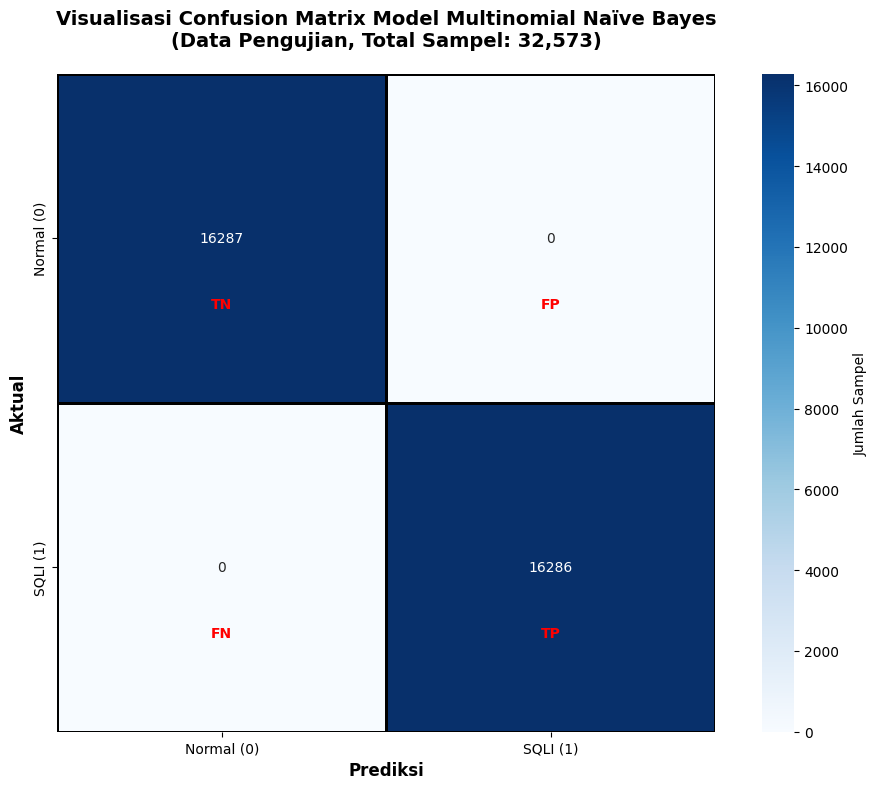

Visualisasi Confusion Matrix berhasil dibuat dan disimpan sebagai 'confusion_matrix_visualization.png'


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create confusion matrix visualization
# Tahap visualisasi confusion matrix dengan heatmap seaborn.
# Nilai cm_data di-hardcode mengikuti hasil Tabel 4.2 agar konsisten
# dengan laporan. Label TN/FP/FN/TP di-overlay pada tiap sel sebagai
# penanda posisi kesalahan model bagi pembaca awam.
fig, ax = plt.subplots(figsize=(10, 8))

# Data from confusion matrix
cm_data = np.array([[16287, 0], [0, 16286]])
class_labels = ['Normal (0)', 'SQLI (1)']

# Create heatmap
sns.heatmap(cm_data, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels,
            cbar_kws={'label': 'Jumlah Sampel'},
            ax=ax, square=True, linewidths=2, linecolor='black')

ax.set_xlabel('Prediksi', fontsize=12, fontweight='bold')
ax.set_ylabel('Aktual', fontsize=12, fontweight='bold')
ax.set_title('Visualisasi Confusion Matrix Model Multinomial Naïve Bayes\n(Data Pengujian, Total Sampel: 32,573)', 
             fontsize=14, fontweight='bold', pad=20)

# Add text annotations for clarity
for i in range(2):
    for j in range(2):
        text = ax.text(j + 0.5, i + 0.7, ['TN', 'FP', 'FN', 'TP'][i*2 + j],
                      ha="center", va="center", color="red", fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('confusion_matrix_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualisasi Confusion Matrix berhasil dibuat dan disimpan sebagai 'confusion_matrix_visualization.png'")